# Module 01 — Integrating everything: ODE, maps, DDE, SDE

Every study of a dynamical system begins the same way: you hand the solver a
vector field (or a map, or a stochastic drift), a starting point, and a horizon,
and it hands you back a **trajectory**. In `tsdynamics` that contract is the same
whether the system is a smooth flow, an iterated map, a delay-differential
equation with infinite-dimensional history, or a noisy SDE. Master this one verb
— *integrate* — and the whole catalogue of 154 systems opens up.

In this module we take the four families through their paces on a single, uniform
stepping protocol, and we meet the machinery you will lean on all week: solver
**methods**, compute **backends**, **event** detection, and the low-level
`reinit → step → state` loop that powers interactive control.

**You will learn to:**
- integrate an ODE and steer it with `final_time`, `dt`, `ic`, `method`, `rtol`/`atol`
- pick a solver method (explicit vs. stiff `bdf`, and `method="auto"`)
- swap the compute backend (`interp` / `jit` / `reference`) and know when it matters
- iterate a **map**, integrate a **DDE** with a history, and run a seeded **SDE**
- detect **events** (section crossings, terminal stopping) during integration
- drive a system by hand with the `reinit`/`step`/`state`/`time` protocol

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. The core verb: `integrate`

The Lorenz system,

$$\dot x = \sigma(y-x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = xy - \beta z,$$

is our reference flow. `integrate` returns a `Trajectory` — a thin wrapper around
the sampled state array `traj.y` (shape `(n_steps, dim)`), the time grid `traj.t`,
and a `traj.meta` provenance dict. Because Lorenz declares `variables=("x","y","z")`,
you can also pull named channels with `traj["x"]`.

In [2]:
lor = ts.Lorenz()
traj = lor.integrate(final_time=60.0, dt=0.01, ic=[1.0, 1.0, 1.0])

print("y shape:", traj.y.shape)          # (6001, 3)
print("t range:", traj.t[0], "->", traj.t[-1])
print("meta method / backend:", traj.meta["method"], "/", traj.meta["backend"])
print("named channel traj['x'][:3]:", np.round(traj["x"][:3], 4))

fig = traj.plot(kind="phase_portrait_3d", components=["x", "y", "z"], color_by="time")
fig.axes[0].set_title("Lorenz attractor")
plt.show()

y shape: (6001, 3)
t range: 0.0 -> 60.0
meta method / backend: rk45 / interp
named channel traj['x'][:3]: [1.     1.0126 1.0488]


The butterfly. `color_by="time"` shades the curve from start to finish, so you can
read the orbit's history off the picture. Everything downstream in the workshop —
Lyapunov exponents, Poincaré sections, basins — starts from a `Trajectory` like this.

## 2. Choosing a solver method

`method=` selects the integration kernel. For non-stiff flows the explicit
Runge–Kutta family is the workhorse: `"rk45"` (Dormand–Prince, the default),
`"tsit5"` (Tsitouras), `"dop853"` (8th order), `"bs3"`, and the fixed-step `"rk4"`.
On a well-behaved horizon they agree to solver tolerance. Let's compare three on a
short, non-chaotic stretch of Lorenz where the methods track each other closely.

In [3]:
ic = [1.0, 1.0, 1.0]
common = dict(final_time=3.0, dt=0.01, ic=ic, rtol=1e-9, atol=1e-11)
t_rk45  = lor.integrate(method="rk45",  **common)
t_tsit5 = lor.integrate(method="tsit5", **common)
t_dop8  = lor.integrate(method="dop853", **common)

d_tsit5 = np.max(np.abs(t_rk45.y - t_tsit5.y))
d_dop8  = np.max(np.abs(t_rk45.y - t_dop8.y))
print(f"max |rk45 - tsit5|  over 3 t.u.: {d_tsit5:.2e}")
print(f"max |rk45 - dop853| over 3 t.u.: {d_dop8:.2e}")

max |rk45 - tsit5|  over 3 t.u.: 4.56e-08
max |rk45 - dop853| over 3 t.u.: 6.90e-08


At tight tolerances the three explicit methods differ by only a handful of ULPs
times the tolerance — they are solving the *same* ODE. On a chaotic attractor those
tiny differences would eventually blow up to the size of the attractor (that is
sensitive dependence — Module 04), which is exactly why we compared on a short
horizon here.

### Stiff systems and `method="auto"`

Some systems are **stiff** — they carry widely separated timescales that make
explicit methods take absurdly tiny steps. For those, an implicit kernel like
`"bdf"` (variable-order backward differentiation, 1–5) is the right tool, and
`tsdynamics` builds the required Jacobian for you. The driven **Duffing** oscillator

$$\ddot x + \delta\dot x + \alpha x + \beta x^3 = \gamma\cos(\omega t)$$

declares `_default_method="bdf"`, so `integrate` picks it automatically. Note Duffing
has **no** `variables`, so we index components positionally with `traj.y[:, i]`.

We drive it in the classic **twin-well Holmes** regime ($\alpha=-1,\beta=1$: a double
well) with $\gamma=0.30,\ \delta=0.25,\ \omega=1$, where the forced oscillator is
**chaotic** — before calling it a *strange* attractor we prove it, by checking the
largest Lyapunov exponent is clearly **positive** (Module 04 does Lyapunov in depth).

Duffing resolved method: bdf  all finite: True
largest Lyapunov exponent: 0.097 -> POSITIVE => genuinely chaotic (a strange attractor)
x visits both wells, range: 2.92


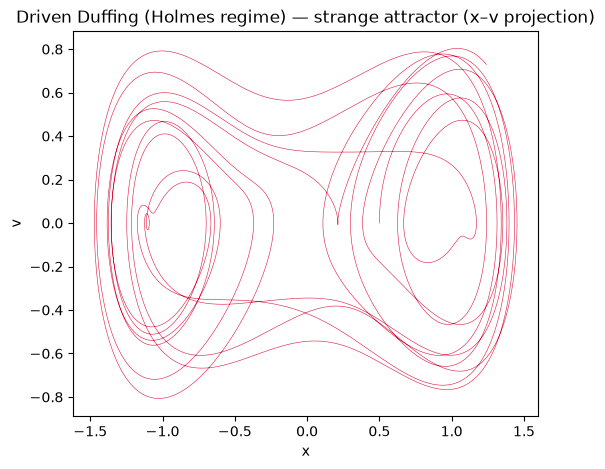

In [4]:
duff = ts.Duffing().with_params(alpha=-1.0, beta=1.0, delta=0.25, gamma=0.30, omega=1.0)
dtraj = duff.integrate(final_time=120.0, dt=0.02, ic=[0.5, 0.0, 0.0])  # bounded IC into the wells
exps = ts.lyapunov_spectrum(duff, final_time=400.0, dt=0.02, ic=[0.5, 0.0, 0.0])
print("Duffing resolved method:", dtraj.meta["method"], " all finite:", np.all(np.isfinite(dtraj.y)))
print("largest Lyapunov exponent:", round(float(np.max(exps)), 3),
      "-> POSITIVE => genuinely chaotic (a strange attractor)")
print("x visits both wells, range:", round(float(np.ptp(dtraj.y[:, 0])), 2))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(dtraj.y[:, 0], dtraj.y[:, 1], lw=0.4, color="crimson")  # x vs v
ax.set(xlabel="x", ylabel="v", title="Driven Duffing (Holmes regime) — strange attractor (x–v projection)")
plt.show()

The exponent is positive, so the "strange attractor" label is earned, not assumed. A
cleaner fingerprint is a **stroboscopic section**: sample the state once per forcing
period ($T = 2\pi/\omega = 2\pi$). A *periodic* orbit would collapse to a few points;
a strange attractor leaves a **fractal cloud** — the Poincaré map of the driven flow.

stroboscopic samples: 600  x-spread: 2.66 (a cloud, not a point)


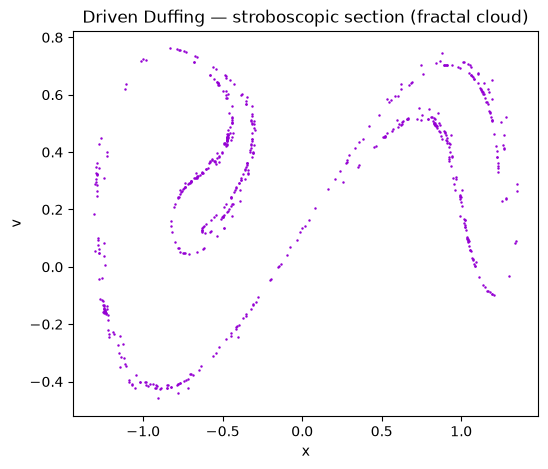

In [5]:
strobe = ts.StroboscopicMap(duff, 2 * np.pi / 1.0).trajectory(600, transient=50)
print("stroboscopic samples:", strobe.y.shape[0],
      " x-spread:", round(float(np.ptp(strobe.y[:, 0])), 2), "(a cloud, not a point)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(strobe.y[:, 0], strobe.y[:, 1], ".", ms=1.5, color="darkviolet")
ax.set(xlabel="x", ylabel="v", title="Driven Duffing — stroboscopic section (fractal cloud)")
plt.show()

If you *don't* know whether a system is stiff, pass `method="auto"`: it probes the
Jacobian spectrum at the start state and picks `bdf` (stiff) or `rk45` (non-stiff).
The resolved kernel is recorded in `traj.meta["method"]` — never a mystery.

In [6]:
auto = lor.integrate(final_time=10.0, dt=0.01, ic=ic, method="auto")
print("Lorenz with method='auto' resolved to:", auto.meta["method"])

Lorenz with method='auto' resolved to:

 rk45


## 3. Backends: `interp` vs `jit` vs `reference`

The `backend=` knob chooses *how* the same math is evaluated:

- `"interp"` (default) — the Rust SSA-tape interpreter. Fast, zero warmup.
- `"jit"` — the Cranelift JIT. Compiles the tape to native code; wins on heavy or
  repeated workloads (big ensembles, parameter sweeps, Lyapunov loops).
- `"reference"` — a dependency-light pure-Python SciPy oracle. Slow, but a trustworthy
  independent check.

`interp` and `jit` share the *same lowered tape*, so on a fixed horizon they agree
**bit-for-bit**; `reference` is a different float path and agrees to tolerance.

In [7]:
short = dict(final_time=5.0, dt=0.01, ic=ic, method="rk45")
y_interp = lor.integrate(backend="interp",    **short).y
y_jit    = lor.integrate(backend="jit",       **short).y
y_ref    = lor.integrate(backend="reference", **short).y

print("max |interp - jit|      :", np.max(np.abs(y_interp - y_jit)))       # exactly 0.0
print("max |interp - reference|:", f"{np.max(np.abs(y_interp - y_ref)):.2e}")  # ~1e-4

max |interp - jit|      : 0.0
max |interp - reference|: 2.99e-04


In [8]:
# A quick timing note: JIT pays off when you integrate many times.
import time
def bench(backend, n=40):
    t0 = time.perf_counter()
    for _ in range(n):
        lor.integrate(final_time=20.0, dt=0.01, ic=ic, backend=backend)
    return time.perf_counter() - t0

t_i, t_j = bench("interp"), bench("jit")
print(f"40x interp: {t_i:.3f}s    40x jit: {t_j:.3f}s")

40x interp: 0.082s    40x jit: 0.079s


Both backends are quick here; the JIT's edge grows with the size of the RHS and the
number of repeated calls. Rule of thumb: **`interp` for exploration, `jit` for the
heavy loops** (ensembles, sweeps), **`reference` when you want a second opinion**.

## 4. The output grid and `t0`

`integrate` samples the solution on a uniform grid of spacing `dt` from `t0` up to the
absolute end time `final_time` (so `final_time` must exceed `t0`). `dt` sets the
*output* resolution, not — for adaptive methods — the internal step. Shifting `t0`
relabels the time axis, handy when you stitch runs together.

In [9]:
seg = lor.integrate(final_time=12.0, dt=0.5, ic=ic, t0=10.0)   # end time 12, start 10
print("t grid:", seg.t)          # [10.0, 10.5, 11.0, 11.5, 12.0]
print("n samples:", seg.y.shape[0])

t grid: [10.  10.5 11.  11.5 12. ]
n samples: 5


## 5. Maps: iterate instead of integrate

Discrete maps $x_{n+1} = f(x_n)$ have no solver — you *iterate*. The verb is
`.iterate(steps=...)`, and the returned `Trajectory` has one row per iterate. The
Hénon map,

$$x_{n+1} = 1 - a x_n^2 + y_n, \qquad y_{n+1} = b x_n,$$

traces its famous folded attractor as a point cloud.

Henon iterates: (6000, 2)


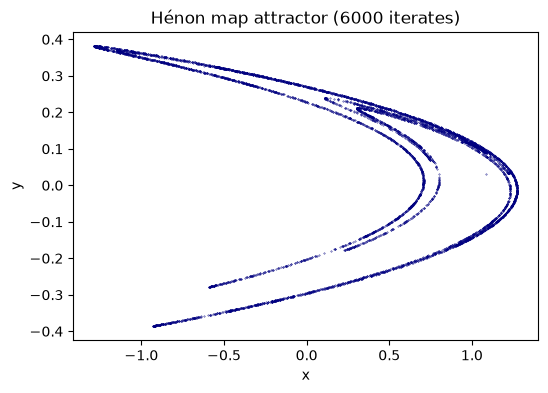

In [10]:
henon = ts.Henon()
hpts = henon.iterate(steps=6000, ic=[0.1, 0.1])
print("Henon iterates:", hpts.y.shape)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hpts["x"], hpts["y"], ".", ms=0.6, color="navy")
ax.set(xlabel="x", ylabel="y", title="Hénon map attractor (6000 iterates)")
plt.show()

The logistic map $x_{n+1} = r\,x_n(1-x_n)$ is 1-D; at $r=3.9$ it is chaotic. We'll
turn its parameter sweep into the classic bifurcation cascade in Module 03.

In [11]:
log = ts.Logistic()             # params: r=3.9
lpts = log.iterate(steps=2000, ic=[0.2])
print("Logistic r =", log.params["r"], " last 5 iterates:", np.round(lpts.y[-5:, 0], 4))

Logistic r = 3.9  last 5 iterates: [0.9472 0.1952 0.6126 0.9256 0.2687]


## 6. Delay-differential equations (DDEs)

A DDE depends on the state at an earlier time: Mackey–Glass,

$$\dot x(t) = \frac{\beta\, x(t-\tau)}{1 + x(t-\tau)^{n}} - \gamma\, x(t),$$

has *infinite-dimensional* history, so instead of an initial point you supply a
**history function** over $[-\tau, 0]$. Use a non-equilibrium history (a constant at
the fixed point would give trivial dynamics).

In [12]:
mg = ts.MackeyGlass()           # 1-D, variables=("x",)
mgtraj = mg.integrate(final_time=300.0, dt=0.5,
                      history=lambda s: [1.0 + 0.1 * np.sin(0.2 * s)])
print("Mackey-Glass samples:", mgtraj.y.shape)

# The infinite-dimensional attractor lives in a delay embedding x(t) vs x(t-tau).
fig = mgtraj.plot(kind="delay", tau=17.0)
fig.axes[0].set_title(r"Mackey–Glass delay embedding  $x(t)$ vs $x(t-17)$")
plt.show()

Mackey-Glass samples: (601, 1)


The `kind="delay"` recipe plots $x(t)$ against $x(t-\tau)$ (with `tau` in time units,
converted to a sample lag via `meta["dt"]`). The folded loop is the signature of
Mackey–Glass chaos — a genuinely high-dimensional attractor reconstructed from one
scalar channel. We'll do this reconstruction *from measured data* in Module 05.

## 7. Stochastic differential equations (SDEs)

An SDE adds noise: $dX = f(X)\,dt + g(X)\,dW$. Here `dt` sets **both** the output grid
and the noise scale $\sqrt{dt}$, and a `seed` makes the realisation reproducible. We
use the Ornstein–Uhlenbeck process, a mean-reverting Gaussian.

seed 1 == seed 1 (reproducible): True
seed 1 != seed 2 (different noise): True


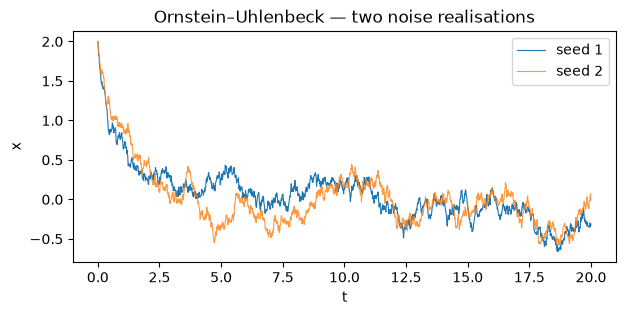

In [13]:
ou = ts.OrnsteinUhlenbeck()
run_a = ou.integrate(final_time=20.0, dt=0.01, seed=1, method="euler_maruyama")
run_b = ou.integrate(final_time=20.0, dt=0.01, seed=1)   # same seed -> identical
run_c = ou.integrate(final_time=20.0, dt=0.01, seed=2)   # different seed -> different path

print("seed 1 == seed 1 (reproducible):", np.array_equal(run_a.y, run_b.y))
print("seed 1 != seed 2 (different noise):", not np.array_equal(run_a.y, run_c.y))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(run_a.t, run_a["x"], lw=0.8, label="seed 1")
ax.plot(run_c.t, run_c["x"], lw=0.8, label="seed 2", alpha=0.8)
ax.set(xlabel="t", ylabel="x", title="Ornstein–Uhlenbeck — two noise realisations")
ax.legend()
plt.show()

For statistics you rarely want one path — you want a *batch*. `ensemble(ics, ...)`
fans out many trajectories (seed of trajectory *i* depends only on `i`, so the batch
is reproducible) and returns the array of **final** states.

ensemble final states shape: (200, 1)


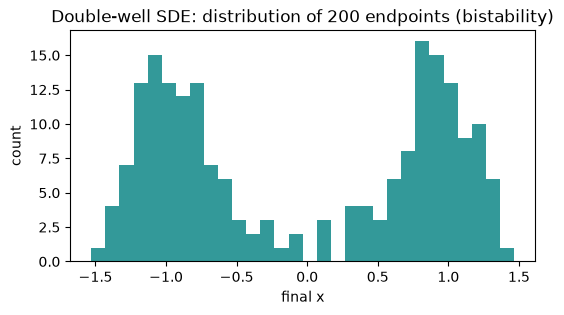

In [14]:
finals = ts.DoubleWell().ensemble([[0.1]] * 200, final_time=10.0, dt=0.01, seed=3)
finals = np.asarray(finals)
print("ensemble final states shape:", finals.shape)   # (200, 1)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(finals[:, 0], bins=30, color="teal", alpha=0.8)
ax.set(xlabel="final x", ylabel="count",
       title="Double-well SDE: distribution of 200 endpoints (bistability)")
plt.show()

The two humps are the two wells — noise lets trajectories hop between them. This is a
baby version of the **basin / tipping** picture we build in Module 07 and use to judge
grid stability in the capstone.

## 8. Events: acting on what the trajectory does

Often you want to *react* to a condition during integration — record every time the
orbit crosses a plane, or **stop** when it leaves a region. `run(events=[...])` gives
you a scipy-shaped events surface (ODEs only). An event is either a plane tuple
`(axis, offset, "up"/"down"/"both")` or a callable `g(y, t)` (with `y` an accessor:
`y(0)`, `y(1)`, …) whose zeros are the crossings.

In [15]:
# Record every upward crossing of the plane z = 27 (the classic Lorenz section).
sol = ts.Lorenz().run(final_time=60.0, dt=0.01, ic=[1, 1, 1], events=[("z", 27.0, "up")])
tcross = sol.meta["t_events"][0]
print(f"z=27 crossed upward {len(tcross)} times; first three at t =", np.round(tcross[:3], 3))

z=27 crossed upward 83 times; first three at t = [0.302 0.859 1.481]


Attach `.terminal = True` to a callable and integration **stops** at the first
crossing — the returned trajectory is truncated there. Here we stop the moment the
orbit's radius hits 40.

In [16]:
def leave_ball(y, t):
    return y(0) ** 2 + y(1) ** 2 + y(2) ** 2 - 40.0 ** 2
leave_ball.terminal = True

sol2 = ts.Lorenz().run(final_time=1e3, dt=0.01, ic=[1, 1, 1], events=[leave_ball])
print("stopped at t =", round(float(sol2.t[-1]), 3),
      "| terminated:", sol2.meta["terminated"],
      "| final radius:", round(float(np.linalg.norm(sol2.y[-1])), 2))

stopped at t = 0.296 | terminated: True | final radius: 40.0


Events are the engine behind Poincaré sections (Module 03) and escape/tipping
detection (Module 07) — the same mechanism, exposed generally.

## 9. The stepping protocol: driving a system by hand

Under `integrate` sits a uniform, resumable protocol implemented by every family:

- `reinit(u)` — set the state (and optionally `t`, `params`) and prime the stepper
- `step(dt)` — advance one `dt` chunk from the *live* state, returning the new state
- `state()`, `time()` — read where you are

This is what you reach for when the next input depends on the current output —
interactive control, feedback, or coupling to an external process. Here we run a manual
loop and confirm it matches `integrate`.

In [17]:
lor2 = ts.Lorenz()
lor2.reinit([1.0, 1.0, 1.0])
manual = [lor2.step(0.01) for _ in range(500)]      # 500 hand-driven steps
manual = np.array(manual)

batch = ts.Lorenz().integrate(final_time=5.0, dt=0.01, ic=[1.0, 1.0, 1.0]).y[1:]  # drop t=0 row
print("manual final state :", np.round(lor2.state(), 5), " at t =", round(lor2.time(), 3))
print("integrate final    :", np.round(batch[-1], 5))
print("max |manual - integrate| over 500 steps:", f"{np.max(np.abs(manual - batch)):.2e}")

manual final state : [-6.51211 -6.97404 23.92413]  at t = 5.0
integrate final    : [-6.51211 -6.97404 23.92413]
max |manual - integrate| over 500 steps: 7.73e-07


The hand-driven loop and the one-shot `integrate` trace the same path. That
equivalence is what makes the stepping protocol a safe basis for real-time control.

## 🧪 Exercises

Fill in each starter cell (replace `# YOUR CODE HERE`). Worked answers are in the
**Solutions** section below — try first!

**Exercise 1 — Tolerance and the Rössler flow.**
Integrate `ts.Rossler()` to `final_time=200` at `dt=0.02` twice: once with
`rtol=1e-4, atol=1e-6` and once with `rtol=1e-10, atol=1e-12` (same `ic=[1,1,1]`).
Report the max absolute difference between the two `traj.y` arrays. *Hint:* on a
chaotic flow the two runs slowly drift apart — that's the point; note how the gap grows
with the horizon.

**Exercise 2 — Drive a map.**
Iterate the Ikeda map (`ts.Ikeda()`) for 4000 steps from `ic=[0.1, 0.1]` and make a
scatter plot of its attractor. *Hint:* `.iterate(steps=..., ic=...)`; Ikeda declares no
`variables`, so index the columns positionally with `traj.y[:, 0]` and `traj.y[:, 1]`.

**Exercise 3 — Count event crossings.**
Run `ts.Rossler()` with `run(...)` and an event on the plane `("x", 0.0, "up")` to
`final_time=200, dt=0.02`. Print how many upward crossings occurred and the first
three crossing times. *Hint:* read `sol.meta["t_events"][0]`.

**Exercise 4 — A reproducible SDE pair.**
Integrate `ts.GeometricBrownianMotion()` to `final_time=15, dt=0.01` with `seed=7`,
then again with `seed=7`, then with `seed=8`. Verify the first two are identical and
the third differs. *Hint:* `np.array_equal`.

**Exercise 5 (stretch) — Backend agreement.**
Integrate `ts.Thomas()` on a *short* horizon (`final_time=4, dt=0.01, ic=[0.1,0.1,0.1]`)
with `backend="interp"` and `backend="jit"` and confirm they agree bit-for-bit
(difference exactly `0.0`). *Hint:* keep the horizon short so sensitive dependence
doesn't mask the point.

In [18]:
# Exercise 1 — Rössler at two tolerances
# YOUR CODE HERE

In [19]:
# Exercise 2 — Ikeda map attractor
# YOUR CODE HERE

In [20]:
# Exercise 3 — count Rössler x=0 upward crossings
# YOUR CODE HERE

In [21]:
# Exercise 4 — reproducible GBM seeds
# YOUR CODE HERE

In [22]:
# Exercise 5 — Thomas interp vs jit bit-for-bit
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

In [23]:
ic1 = [1.0, 1.0, 1.0]
loose = ts.Rossler().integrate(final_time=200.0, dt=0.02, ic=ic1, rtol=1e-4,  atol=1e-6)
tight = ts.Rossler().integrate(final_time=200.0, dt=0.02, ic=ic1, rtol=1e-10, atol=1e-12)
print("max |loose - tight| over 200 t.u.:", f"{np.max(np.abs(loose.y - tight.y)):.4f}")
print("-> the two runs start identical and slowly drift apart: chaos amplifies the tiny")
print("   tolerance difference exponentially, and the gap grows with the horizon")
print("   (we quantify that exponential rate as the Lyapunov exponent in Module 04).")

max |loose - tight| over 200 t.u.: 0.0912
-> the two runs start identical and slowly drift apart: chaos amplifies the tiny
   tolerance difference exponentially, and the gap grows with the horizon
   (we quantify that exponential rate as the Lyapunov exponent in Module 04).


### Solution 2

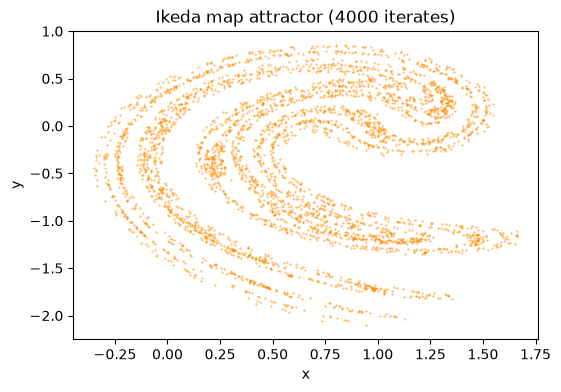

In [24]:
ike = ts.Ikeda().iterate(steps=4000, ic=[0.1, 0.1])   # no `variables` -> index positionally
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ike.y[:, 0], ike.y[:, 1], ".", ms=0.7, color="darkorange")
ax.set(xlabel="x", ylabel="y", title="Ikeda map attractor (4000 iterates)")
plt.show()

### Solution 3

In [25]:
solr = ts.Rossler().run(final_time=200.0, dt=0.02, ic=[1, 1, 1], events=[("x", 0.0, "up")])
xcross = solr.meta["t_events"][0]
print(f"x=0 crossed upward {len(xcross)} times; first three at t =", np.round(xcross[:3], 3))

x=0 crossed upward 34 times; first three at t = [ 3.765 10.08  16.39 ]


### Solution 4

In [26]:
g7a = ts.GeometricBrownianMotion().integrate(final_time=15.0, dt=0.01, seed=7)
g7b = ts.GeometricBrownianMotion().integrate(final_time=15.0, dt=0.01, seed=7)
g8  = ts.GeometricBrownianMotion().integrate(final_time=15.0, dt=0.01, seed=8)
print("seed 7 == seed 7:", np.array_equal(g7a.y, g7b.y))
print("seed 7 != seed 8:", not np.array_equal(g7a.y, g8.y))

seed 7 == seed 7: True
seed 7 != seed 8: True


### Solution 5

In [27]:
sh = dict(final_time=4.0, dt=0.01, ic=[0.1, 0.1, 0.1])
yi = ts.Thomas().integrate(backend="interp", **sh).y
yj = ts.Thomas().integrate(backend="jit",    **sh).y
print("max |interp - jit| for Thomas:", np.max(np.abs(yi - yj)), "(bit-for-bit identical)")

max |interp - jit| for Thomas: 0.0 (bit-for-bit identical)


## Recap / Where next

You now command the one verb that underlies everything: **integrate** (or **iterate**),
across all four families, with control over method, backend, output grid, events, and
the low-level stepping loop.

- **Methods**: explicit RK for smooth flows, `bdf` for stiff, `auto` to decide.
- **Backends**: `interp` to explore, `jit` for heavy loops, `reference` to double-check.
- **Families**: ODE `integrate`, map `iterate`, DDE `integrate(history=...)`,
  SDE `integrate(seed=...)` / `ensemble(...)`.
- **Events** react during a run; the **stepping protocol** drives a system by hand.

Next, **Module 02 — Build your own system**: you'll define custom ODEs, maps, and
SDEs from scratch with the `@staticmethod _equations` / `dim=` / **symengine** contract
— the single most important practical skill for using this library on *your* dynamics.